In [1]:
# Problem 3 Libraries
import numpy as np
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [2]:
# Problem 3(a)(i)
penguins = pandas.read_csv("penguins.csv")
print(f"Shape: {penguins.shape}")
print(penguins.describe())

Shape: (344, 8)
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


In [3]:
# 3(a)(i) continued...
# how many penguins in each species?
print(penguins["species"].value_counts())

# how many penguins on each island?
print(penguins["island"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [18]:
# Problem 4 Libraries
import numpy as np
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
import umap 
from sklearn.linear_model import LogisticRegression

In [19]:
# Problem 4(a)(i)
data = pandas.read_csv("data.csv")
labels = pandas.read_csv("labels.csv")

# drop the first column from data.csv
data = data.drop(columns=[data.columns[0]])

# print the data shape (801 by 20531)
print(f"Data shape: {data.shape}")

# report the count of samples in each tumor class
print(labels["Class"].value_counts())

Data shape: (801, 20531)
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


# Problem 5

In [20]:
# Problem 5 Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [21]:
# Problem 5(a)(i)
bank = pandas.read_csv("bank-full.csv", sep=";")

# print shape, dtypes, and the head
print(f"Shape: {bank.shape}")
print(bank.dtypes)

Shape: (45211, 17)
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


In [22]:
print("First 5 rows:")
print(bank.head())

First 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [23]:
# how many numerical and how many categorical features?
num_numerical = bank.select_dtypes(include=[np.number]).shape[1]
num_categorical = bank.select_dtypes(include=[object]).shape[1]
print(f"Numerical features: {num_numerical}")
print(f"Categorical features: {num_categorical}")

Numerical features: 7
Categorical features: 10


C:\Users\thebr\AppData\Local\Temp\ipykernel_53088\879882629.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_categorical = bank.select_dtypes(include=[object]).shape[1]


In [24]:
# 5(a)(ii)
# what fraction of clients have y == 'yes'?
print(f"Fraction of clients with y == 'yes': {bank['y'].value_counts(normalize=True)['yes']:.4f}")

Fraction of clients with y == 'yes': 0.1170


In [25]:
# 5(a)(iii)
# drop 'duration' from the dataset
bank = bank.drop(columns=["duration"])

This is not a balanced classification problem because there is a large imbalance in the clients that have 'yes' and 'no'.
The trivial 'always predict no' classifier would achieve an 88.3% accuracy, which is already relatively high.

Text(0.5, 1.0, 'Age distribution by target class')

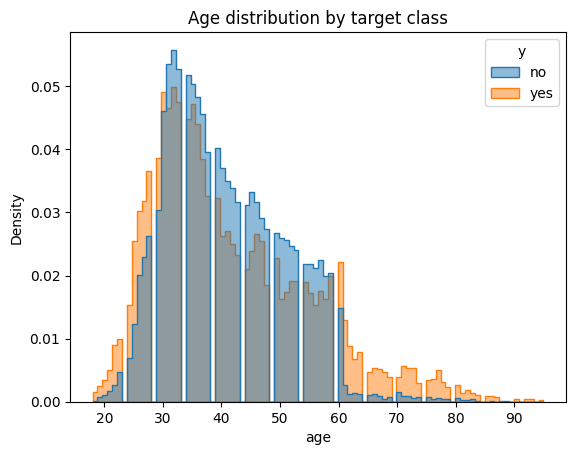

In [26]:
# 5(a)(iv)
# for age and balance, plot histograms split by the target y (overlaid with transparency)
sns.histplot(data=bank, x="age", hue="y", element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Age distribution by target class")
plt.show()

Here, we see the age distributions are relatively similar, but those that said "no" tend to be younger and in their 30s to 60s. Many of those that say "yes" are also generally in the 30s to 60s range, but there are more people in their 60s to 90s that said "yes." 

Text(0.5, 1.0, 'Balance distribution by target class')

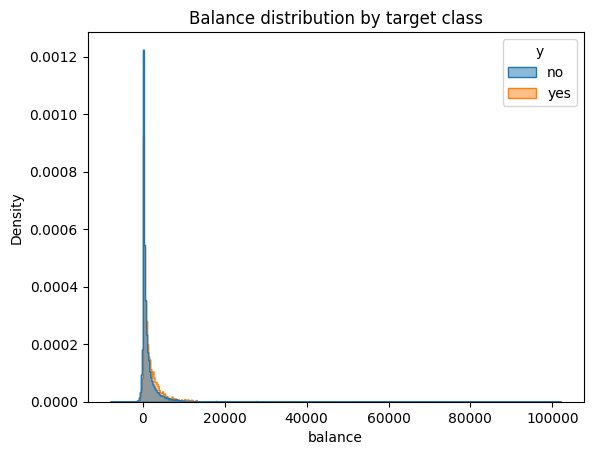

In [27]:
sns.histplot(data=bank, x="balance", hue="y", element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Balance distribution by target class")
plt.show()

Here, we see that for both "yes" and "no", the balance is highly concentrated at and near 0, with very few people at 20000 or higher, but still some sitting there. 

C:\Users\thebr\AppData\Local\Temp\ipykernel_53088\1106139440.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=bank, x="poutcome", y=bank["y"].map({"yes": 1, "no": 0}), ci=None)


Text(0.5, 1.0, 'Subscription rate by previous outcome')

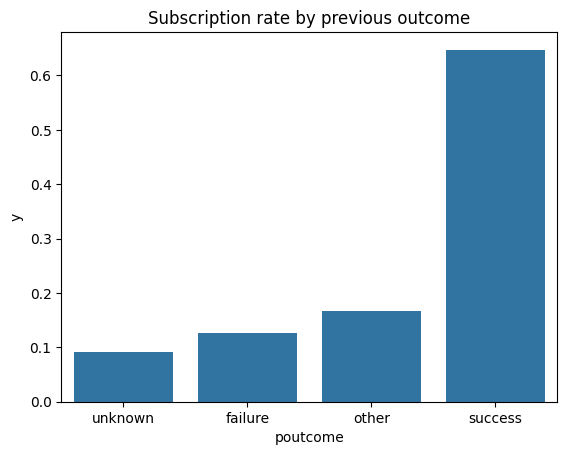

In [ ]:
# do the same for "poutcome" using a bar chart of subscription rate per category
sns.barplot(data=bank, x="poutcome", y=bank["y"].map({"yes": 1, "no": 0}), ci=None)
plt.title("Subscription rate by previous outcome")
plt.show()

Here, we see that if the previous outcome was a "success", the subscription rate was very high, and if not a success, then the subscription rate was relatively low (at or below 0.2).

In [29]:
# 5(b)(i)

# encode the target (yes = 1, no = 0)
bank["y"] = bank["y"].map({"yes": 1, "no": 0})

# split into 60% train, 20% validation, 20% test
np.random.seed(42)
shuffled_indices = np.random.permutation(len(bank))
train_end = int(0.6 * len(bank))
val_end = int(0.8 * len(bank))

train_indices = shuffled_indices[:train_end]
val_indices = shuffled_indices[train_end:val_end]
test_indices = shuffled_indices[val_end:]

train_data = bank.iloc[train_indices]
val_data = bank.iloc[val_indices]
test_data = bank.iloc[test_indices]

# verify that the class balance is preserved across splits
print("Train class balance:")
print(train_data["y"].value_counts(normalize=True))
print("Validation class balance:")
print(val_data["y"].value_counts(normalize=True))
print("Test class balance:")
print(test_data["y"].value_counts(normalize=True))

Train class balance:
y
0    0.881811
1    0.118189
Name: proportion, dtype: float64
Validation class balance:
y
0    0.887193
1    0.112807
Name: proportion, dtype: float64
Test class balance:
y
0    0.882451
1    0.117549
Name: proportion, dtype: float64


The class balance is preserved across the splits.

In [64]:
# 5(b)(ii)

# One-hot encode all categorical features BEFORE splitting
bank_encoded = pd.get_dummies(bank, columns=categorical_cols, drop_first=True)

# Then split
train_data_encoded = bank_encoded.iloc[train_indices]
val_data_encoded = bank_encoded.iloc[val_indices]
test_data_encoded = bank_encoded.iloc[test_indices]

print("Number of features after encoding: ", train_data_encoded.shape[1])

Number of features after encoding:  42


In [65]:
# 5(c)(i)

# fit DecisionTreeClassifier on training data
X_train = train_data_encoded.drop(columns=["y"])
y_train = train_data_encoded["y"]
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train, y_train)

# report training and validation accuracy
X_val = val_data_encoded.drop(columns=["y"])
y_val = val_data_encoded["y"]
y_train_pred = dt_clf.predict(X_train)
y_val_pred = dt_clf.predict(X_val)
train_acc = metrics.accuracy_score(y_train, y_train_pred)
val_acc = metrics.accuracy_score(y_val, y_val_pred)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Training Accuracy: 0.8941
Validation Accuracy: 0.8934


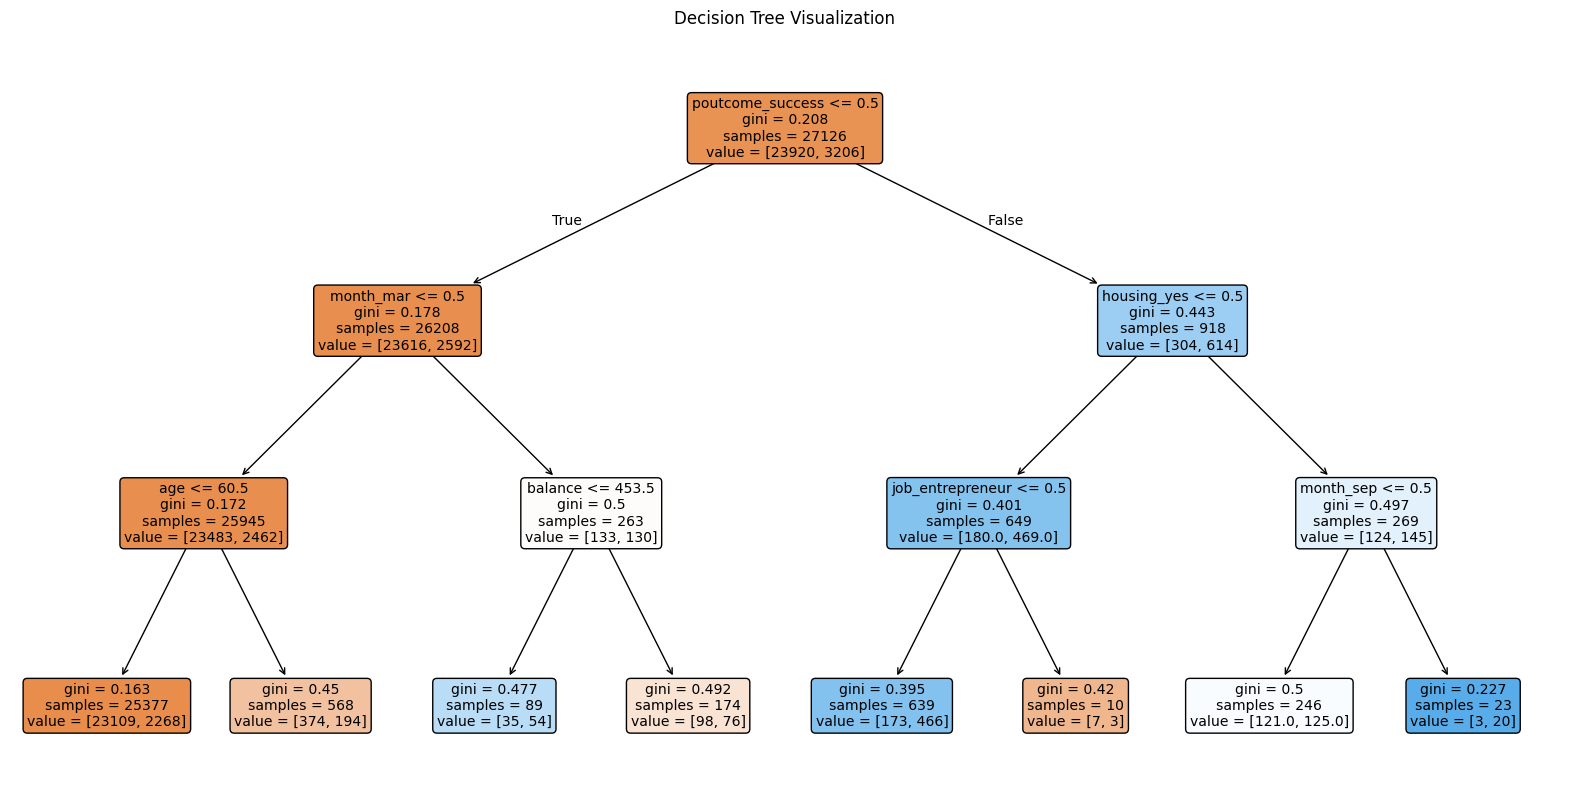

In [66]:
# 5(c)(ii)

# visualize the tree using sklearn.tree.plot_tree with feature_names so the splits are human-readable
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [67]:
# 5(d)(i)

# sweep max_depth within 1, 2, 3, 5, 7, 10, 15, 20, None (where None means unlimited)
# grow until every leaf is pure or below min_samples_split for None
# for each depth, report training and validation accuracy
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
results = []
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)
    train_acc = metrics.accuracy_score(y_train, y_train_pred)
    val_acc = metrics.accuracy_score(y_val, y_val_pred)
    results.append((depth, train_acc, val_acc))
    print(f"Max Depth: {depth}, Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")

Max Depth: 1, Training Accuracy: 0.8932, Validation Accuracy: 0.8945
Max Depth: 2, Training Accuracy: 0.8932, Validation Accuracy: 0.8945
Max Depth: 3, Training Accuracy: 0.8941, Validation Accuracy: 0.8934
Max Depth: 5, Training Accuracy: 0.8951, Validation Accuracy: 0.8943
Max Depth: 7, Training Accuracy: 0.8987, Validation Accuracy: 0.8931
Max Depth: 10, Training Accuracy: 0.9063, Validation Accuracy: 0.8924
Max Depth: 15, Training Accuracy: 0.9247, Validation Accuracy: 0.8871
Max Depth: 20, Training Accuracy: 0.9466, Validation Accuracy: 0.8769
Max Depth: None, Training Accuracy: 1.0000, Validation Accuracy: 0.8322


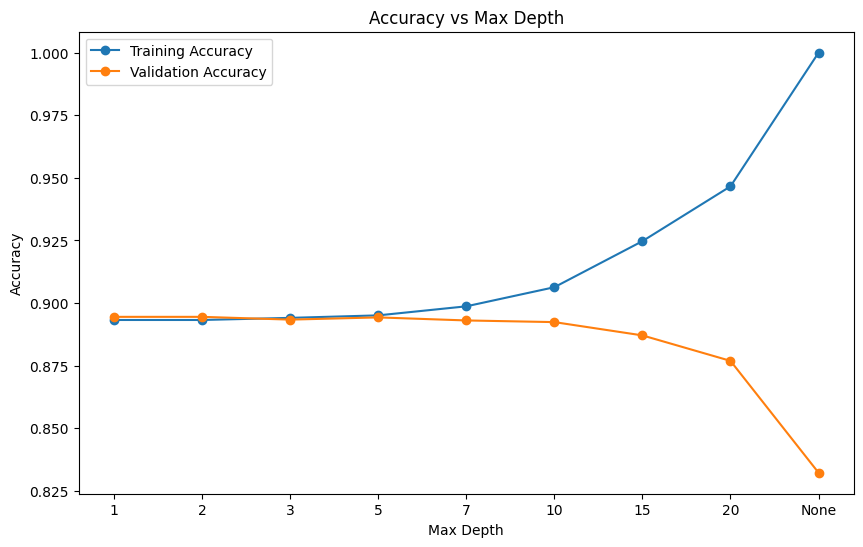

In [68]:
# 5(d)(ii)

# plot training and validation accuracy on the axes as a function of depth
depths_plot = [str(d) for d in depths]
train_accs = [r[1] for r in results]
val_accs = [r[2] for r in results]
plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_accs, marker='o', label='Training Accuracy')
plt.plot(depths_plot, val_accs, marker='o', label='Validation Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Max Depth")
plt.legend()
plt.show()

 - The validation accuracy peaks at Depth 5 (will not choose Depth 1 or 2 because later on, this does not produce good results).
 - After the peak, training accuracy keeps improving while validation degrades, and this is due to overfitting.
 - There is not much error from bias (simple assumptions) at a low depth, but there is a lot of error from variance (overfitting) as the max depth of the decision tree gets larger. This is similar to what we saw with the previously-fitted models where too complex of a model causes the model to memorize the training data and subsequently perform worse on the validation set.

In [75]:
# 5(e)(ii)

# for each max_depth from part d, perform 5-fold cross-validation on the training set
# this can be done with sklearn.model_selection.KFold or cross_val_score
from sklearn.model_selection import cross_val_score
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    print(f"Max Depth: {depth}, Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Max Depth: 1, Cross-Validation Accuracy: 0.8932 ± 0.0030
Max Depth: 2, Cross-Validation Accuracy: 0.8929 ± 0.0030
Max Depth: 3, Cross-Validation Accuracy: 0.8918 ± 0.0016
Max Depth: 5, Cross-Validation Accuracy: 0.8930 ± 0.0023
Max Depth: 7, Cross-Validation Accuracy: 0.8913 ± 0.0008
Max Depth: 10, Cross-Validation Accuracy: 0.8888 ± 0.0033
Max Depth: 15, Cross-Validation Accuracy: 0.8811 ± 0.0027
Max Depth: 20, Cross-Validation Accuracy: 0.8682 ± 0.0056
Max Depth: None, Cross-Validation Accuracy: 0.8256 ± 0.0043


In [80]:
# 5(e)(ii)

# refit depth 5 on the full training set
best_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
best_clf.fit(X_train, y_train)

# report test accuracy
X_test = test_data_encoded.drop(columns=["y"])
y_test = test_data_encoded["y"]
y_test_pred = best_clf.predict(X_test)
test_acc = metrics.accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8900


Yes, this matches what I would have picked from a single split in part (d).

Text(0.5, 1.0, 'Validation Accuracy vs Min Samples Leaf')

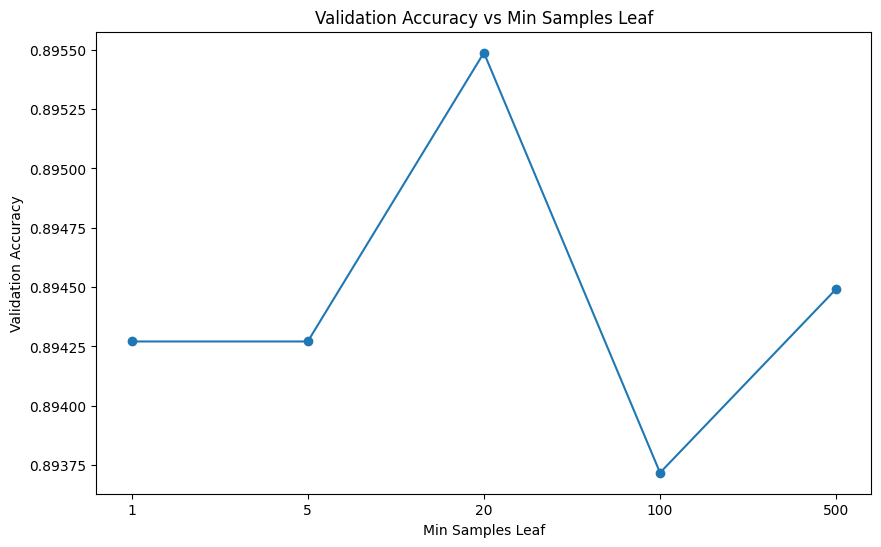

In [81]:
# 5(f)

# sweep min_samples_leaf from 1, 5, 20, 100, 500 at the best depth from part e
best_depth = 5
leaf_sizes = [1, 5, 20, 100, 500]
validation_results = []
for leaf_size in leaf_sizes:
    clf = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=leaf_size, random_state=42)
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)
    val_acc = metrics.accuracy_score(y_val, y_val_pred)
    validation_results.append((leaf_size, val_acc))

# plot validation accuracy vs min_samples_leaf
leaf_sizes_plot = [str(ls) for ls in leaf_sizes]
val_accs_leaf = [r[1] for r in validation_results]
plt.figure(figsize=(10, 6))
plt.plot(leaf_sizes_plot, val_accs_leaf, marker='o')
plt.xlabel("Min Samples Leaf")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Min Samples Leaf")

In [83]:
# report combined-test accuracy at the combination of 5 depth and 20 samples per leaf
final_clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
final_clf.fit(X_test, y_test)
final_test_acc = metrics.accuracy_score(y_test, final_clf.predict(X_test))
print(f"Final Test Accuracy (Depth=5, Min Samples Leaf=20): \n{final_test_acc:.4f}")

Final Test Accuracy (Depth=5, Min Samples Leaf=20): 
0.8964


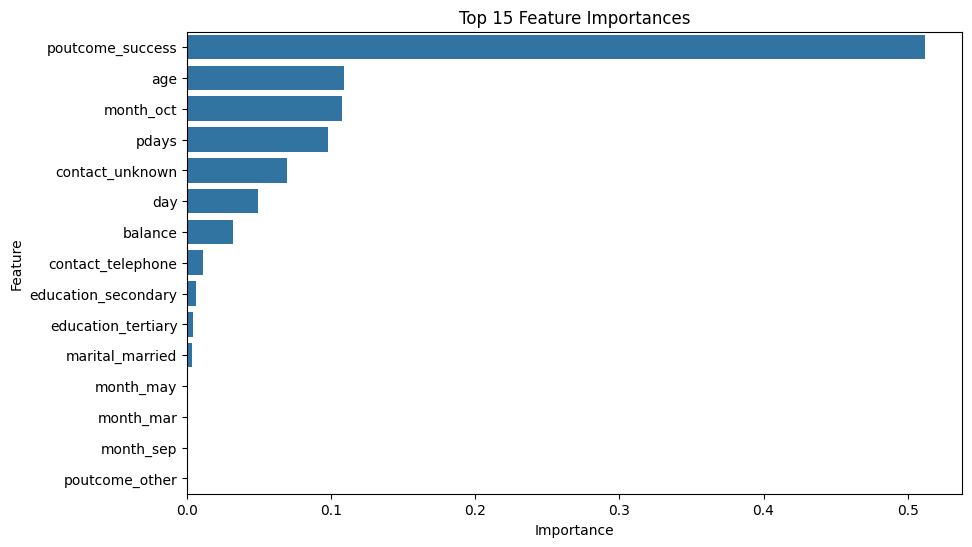

In [84]:
# 5(g)(i)

# extract tree.feature_importances_ 
# and plot the top 15 features by importance
feature_importances = final_clf.feature_importances_
top_15_indices = feature_importances.argsort()[::-1][:15]
top_15_features = X_train.columns[top_15_indices]
top_15_importances = feature_importances[top_15_indices]
plt.figure(figsize=(10, 6))
sns.barplot(x=top_15_importances, y=top_15_features)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [90]:
# 5(g)(ii)
# See the below markdown cell.

 - The features that dominate are poutcome_success, age, month_oct, pdays, and contact_unknown. 
 - These match the patterns we saw in the EDA in part (a)(iv) because the tree did pick up on poutcome, contact, month, and age as four of the five most influential features.

In [87]:
# 5(h)

# make sure to standardize the numerical features first using their mean and std
X_train_mean = X_train.mean()
X_train_std = X_train.std()
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_val_scaled = (X_val - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

# train a logistic regression baseline on the same one-hot-encoded features
logreg_clf = LogisticRegression(max_iter=1000, random_state=42)
logreg_clf.fit(X_train_scaled, y_train)

# report test accuracy
y_test_pred_logreg = logreg_clf.predict(X_test_scaled)
logreg_test_acc = metrics.accuracy_score(y_test, y_test_pred_logreg)

print("Logistic Regression Test Accuracy: {:.4f}".format(logreg_test_acc))
print("Decision Tree Test Accuracy: {:.4f}".format(test_acc))

Logistic Regression Test Accuracy: 0.8897
Decision Tree Test Accuracy: 0.8900


 - The decision tree is faster to train.
 - The decision tree is easier to explain to a non-specialist, as it lays out "why" classifications are being made in terms of the features themselves.
 - The decision tree would likely handle a new categorical level more gracefully, as we can simply add another layer to the decision tree to handle this (if it is influential).

In [88]:
# 5(i)

# for the best tree, compute precision and recall on the test set
y_test_pred_tree = best_clf.predict(X_test)
precision = metrics.precision_score(y_test, y_test_pred_tree)
recall = metrics.recall_score(y_test, y_test_pred_tree)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.6133
Recall: 0.1731


 - The bank should care much more about the False Negatives, where the model predicted that the person "will not subscribe" but he/she would have actually said yes. This is because the cost of wasting one phone call on a False Positive does not matter as much as the cost of a lost paying customer.
 - I would tune the prediction threshold down to better serve the bank so that the number of False Negatives is minimized. This way, we get more False Positives, but we minimize the number of subscriptions lost.

In [ ]:
# 5(j) 
# See the below markdown cell.

 - One thing we can try next is weighting the "Yes" labels more than the "No" labels so that deeper patterns are actually learned. This would force the Decision Tree to learn the patterns of subscribers rather than just guessing "No" for high accuracy.
 - Before deploying the model in production, I would investigate the time at which the data was collected, as it is logical that the decision of whether a person should subscribe to a bank is highly dependent on the economy and political environment.